Aplicación con `data_1.txt`

El archivo `data_1.txt` contiene un conjunto sencillo para regresión lineal. La primera columna corresponde a la variable independiente y la segunda a la variable objetivo.

Los datos representan el precio de una vivienda en función de la población de una ciudad. La población está expresada en unidades de 10.000 habitantes y el precio en unidades de 10.000 dólares.

### Actividad 1

1. Cargue los datos y represéntelos mediante un diagrama de dispersión.
2. Ajuste un modelo `LinearRegression`.
3. Obtenga y muestre el término independiente y la pendiente.
4. Obtenga y muestre los parámetros del modelo.
5. Grafique la recta ajustada sobre los datos.
6. Interprete el signo y la magnitud de la pendiente.

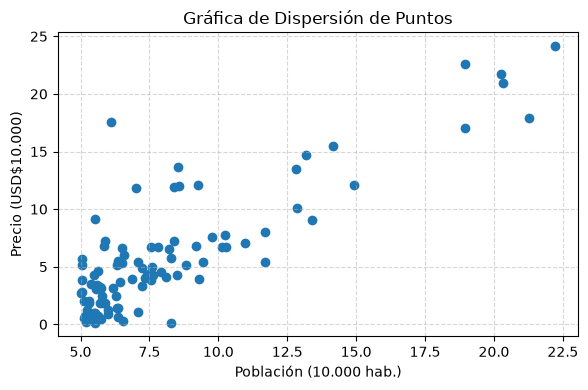

Término independiente  -3.5809620099565436
Pendiente:  1.1697762389135078
Parámetros del modelo:  {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False, 'tol': 1e-06}


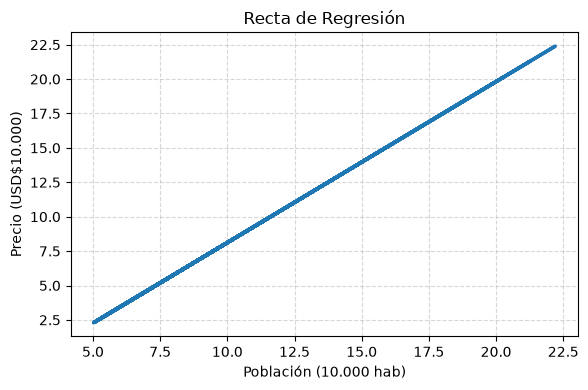

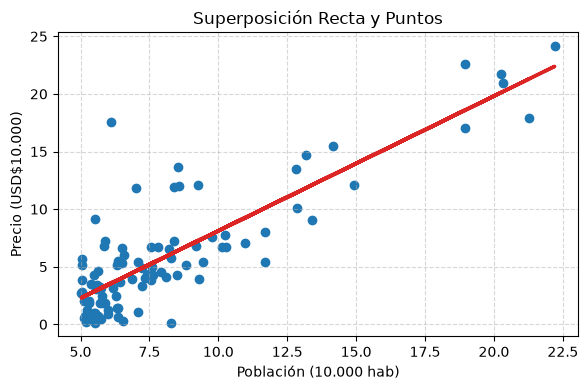

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

datos1 = np.loadtxt('./data/data_1.txt', delimiter=",")
#x1  varibale independiente.
x1 = datos1[:, 0].reshape(-1,1) #Se toma el primer dato de cada fila y reshape permite transformar a un arreglo de una columna con la cantidad de filas que se extrajeron del arreglo original
#y1 variable objetivo
y1 = datos1[:,1]

#Gráfica de dispersión
plt.figure(figsize=(6, 4))
plt.scatter(x1, y1, alpha=1)
plt.title("Gráfica de Dispersión de Puntos")
plt.xlabel("Población (10.000 hab.)")
plt.ylabel("Precio (USD$10.000)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafica_1_puntos.png', dpi=300)
plt.show()
plt.close()

#Ajustamos a regresión lineal
modelo1 = LinearRegression()
modelo1.fit(x1,y1)

#Obtenemos término independiente y pendiente
w0 = modelo1.intercept_
w1 = modelo1.coef_[0]

print("Término independiente ", w0)
print("Pendiente: ", w1)


#Obtenemos los parámetros del modelo
par_modelo = modelo1.get_params()
print("Parámetros del modelo: ", par_modelo)


#Gráfica Regresión
plt.figure(figsize=(6, 4))
plt.plot(x1, modelo1.predict(x1), linewidth=2.5)
plt.title('Recta de Regresión')
plt.xlabel('Población (10.000 hab)')
plt.ylabel('Precio (USD$10.000)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafica_2_recta.png', dpi=300)
plt.show()
plt.close()


#Superposición de gráficas
plt.figure(figsize=(6, 4))
plt.scatter(x1, y1)
plt.plot(x1, modelo1.predict(x1), color='#DC2626', linewidth=2.5)
plt.title('Superposición Recta y Puntos')
plt.xlabel('Población (10.000 hab)')
plt.ylabel('Precio (USD$10.000)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('grafica_2_recta.png', dpi=300)
plt.show()
plt.close()

1.6: El signo de la pendiente indica que existe una relación positiva entre las variables (a medida que aumenta la población, aumenta el precio de la vivienda). En cuanto a la magnitud, se puede referir que por cada 10.000 habitantes, el precio de las viviendas aumenta, aproximadamente, en un 1,17.

Entrenamiento y prueba con data_2.csv 
Para analizar desempeño sobre datos no utilizados durante el ajuste, dividiremos data_2.csv en un conjunto de entrenamiento y otro de prueba.

Actividad 2
1. Separe los datos en entrenamiento y prueba.
2. Ajuste LinearRegression usando únicamente el conjunto de entrenamiento.
3. Calcule MSE, RMSE y  R2  en ambos conjuntos.
4. Compare los errores y discuta si existe evidencia de un problema de generalización.

In [ ]:
#Para esta actvividad asumimos que los datos siguen la línea de la acividad anterior, columna 1 cant hab, columna 2 precio vivienda

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

viviendas_df = pd.read_csv("./data/data_2.csv")
x2 = viviendas_df.iloc[:,[0]] #El método iloc permite tomar todas las filas de la columna, no hace falta reshape porque los dobles corchetes devuelven un arreglo bidimensional
y2 = viviendas_df.iloc[:, 1]

x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

#Ajustamos con regresión lineal solo utilizando los datos de entrenamiento
modelo2 = LinearRegression()
modelo2.fit(x2_train, y2_train)

#Predicción y cálculo de métricas
y2_train_pred = modelo2.predict(x2_train) #Se calulan los valores estimados de la variable objetivo, utilizando el set de entrenamiento
y2_test_pred = modelo2.predict(x2_test) #Acá se hace lo mismo, pero con el set de prueba, simulando cómo funcionaría con casos nuevos

#Métricas para el set train
mse2_train = mean_squared_error(y2_train,y2_train_pred) #Se calcula el MSE con los datos y la predicción, luego se calcula el RMSE a partir de este
rmse2_train = np.sqrt(mse2_train)
r2_2train = r2_score(y2_train, y2_train_pred) #Se calcula el valor R2 con los datos y la predicción

#Métricas para el set test
mse2_test = mean_squared_error(y2_test, y2_test_pred)
rmse2_test = np.sqrt(mse2_test)
r2_2test = r2_score(y2_test, y2_test_pred)

print("Métricas Entrenamiento")
print("MSE: ", round(mse2_train,4))
print("RMSE: ", round(rmse2_train, 4)) 
print("R2: ", round(r2_2train,4))
print("Métricas Test")
print("MSE: ", round(mse2_test, 4))
print("RMSE: ", round(rmse2_test,4)) 
print("R2: ", round(r2_2test,4))

Métricas Entrenamiento
MSE:  4.311361507419819
RMSE:  2.0763818308345456
R2:  0.915387859825229
Métricas Test
MSE:  4.307990786392767
RMSE:  2.075569990723697
R2:  0.9151032902527314
